---
title: JupyterLite `XEUS-SQLite` (przewodnik)
subtitle: Operacje DQL na relacyjnej bazie danych w JupyterLite - dla analityków danych
author:
  - name: Krzysztof Molenda
    affiliations: URK/WIPiE/KIPLiIS
    email: krzysztof.molenda@urk.edu.pl
date: 2026-03-02
---

---


> `Xeus-sqlite` to jądro Jupyter oparte na bibliotece Xeus, które pozwala wykonywać zapytania SQL dla bazy SQLite bezpośrednio w notatniku jako “język” kernela zamiast Pythona. W JupyterLite działa całkowicie po stronie przeglądarki jako WebAssembly (WASM), co umożliwia interaktywną pracę z SQLite bez serwera i instalacji po stronie użytkownika.
>
> Wykorzystywany jest głównie w nauczaniu SQL i podstaw baz danych z wykorzystaniem SQLite w przeglądarce, bez instalacji lokalnej i bez dostępu do serwera, idealne dla kursów i dokumentacji interaktywnej.

---

```{error} WAŻNE
Środowisko **XEUS-SQLite nie nadaje się do projektowania i tworzenia baz danych** (wykonywania zapytań DDL typu `CREATE TABLE` z relacjami), ze względu na krytyczne ograniczenia architektoniczne silnika WebAssembly (WASM):

* **Błędy wirtualnego systemu plików (VFS):** Zapis zmian schematu bazy, indeksów (`UNIQUE`) czy kluczy obcych (`FOREIGN KEY`) uszkadza nagłówek pliku w pamięci wirtualnej przeglądarki, skutkując nieodwracalnym błędem `Error: database disk image is malformed`.
* **Brak obsługi blokad plików:** Pamięć podręczna przeglądarki (IndexedDB / MEMFS) nie wspiera natywnego blokowania plików (POSIX locking), wymaganego przez SQLite przy tworzeniu złożonych struktur relacyjnych.
* **Problem z wyczyszczeniem bufora:** Po wystąpieniu błędu restart jądra ani usunięcie pliku `.db` z interfejsu JupyterLite nie przywracają sprawności — przeglądarka przetrzymuje uszkodzony stan w pamięci lokalnej.
* **Porzucony rozwój:** Jądro `xeus-sqlite` w JupyterLite jest oficjalnie oznaczone jako przestarzałe (*deprecated*) i pozbawione wsparcia dla pełnego cyklu tworzenia baz relacyjnych.

**Do czego XEUS-SQLite nadal się nadaje:**

* Wykonywanie zapytań odczytu i analizy danych (**`SELECT`**, **`JOIN`**, **`GROUP BY`**, **CTE**, **Window Functions**) na gotowej, wcześniej wczytanej bazie (`%LOAD`).
* Proste operacje na pojedynczych tabelach bez złożonych więzów integralności.

**Zalecane rozwiązanie alternatywne:**
Do ćwiczeń obejmujących projektowanie relacji od zera należy przełączyć jądro notatnika na **Python 3 (Pyodide)** i pracować z natywnym modułem `sqlite3` na bazie w pamięci RAM (`sqlite3.connect(":memory:")`).
```

Kernel `xsqlite` zapewnia funkcjonalność _magicznych instrukcji_ do operacji na bazach danych z poziomu wiersza poleceń i natywne wykonywanie kodu SQL na podłączonej bazie danych.

```{note} Wyjaśnienie - magiczne instrukcje
**Cell magic** to specjalne polecenie IPython, które poprzedza się podwójnym procentem (`%%`) na pierwszej linii i które zmienia sposób wykonania całej komórki w notatniku Jupyter/JupyterLab/JupyterLite. Działa na cały blok komórki, w przeciwieństwie do **line magic** z pojedynczym `%`, które dotyczy tylko jednej linii.
```

---

## 1. Wprowadzenie

Ten przewodnik pokazuje możliwości wykorzystania XEUS-SQLite w analize danych (Eksploracja Danych, Złączenia Relacyjne, Agregacje, CTE oraz Funkcje Okna), na przykładzie demonstracyjnej bazy Chinook (`chinook.db`). Baza ta reprezentuje sklep z muzyką cyfrową (utwory, albumy, artyści, klienci, faktury, playlisty).

Poniżej diagram ER tej bazy.

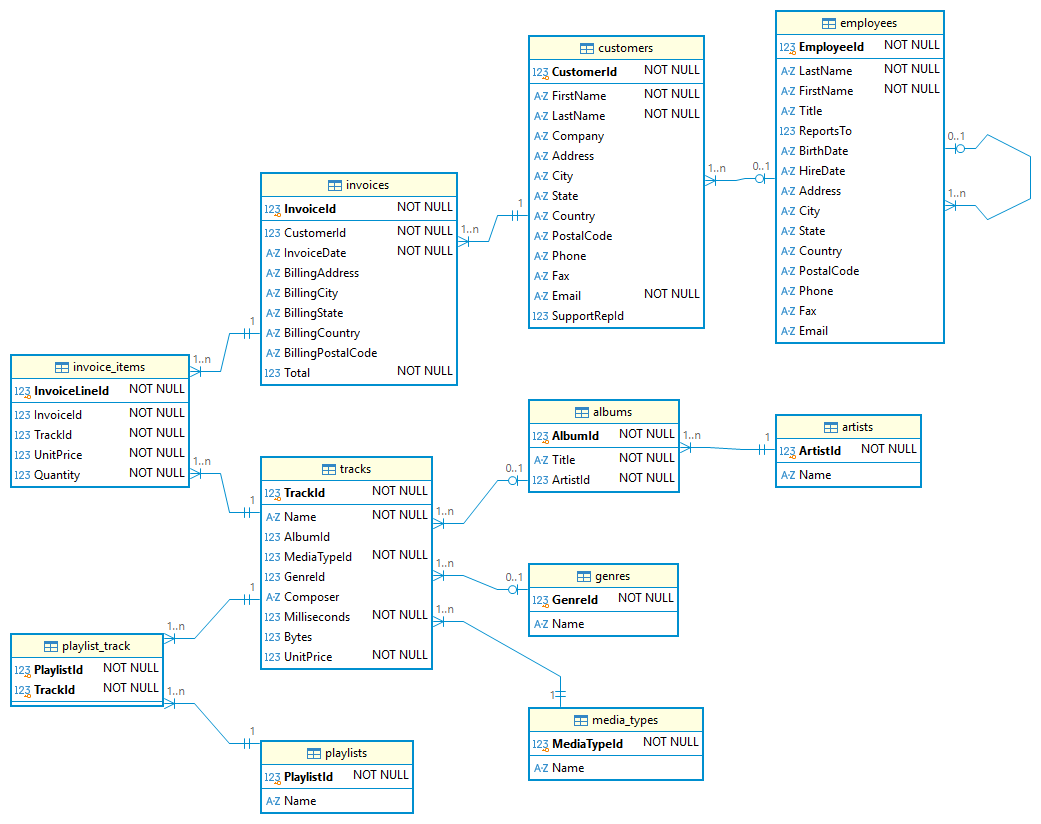

W folderze znajdziesz również pliki zrzutu bazy do SQL, schemat bazy jak również pełny zrzut bazy z danymi.

## 2. Wczytanie i inspekcja bazy danych Chinook

Zaczynamy od załadowania pliku `.db` za pomocą instrukcji magicznej `%LOAD`:

In [ ]:
%LOAD chinook.db

Polecenie `%GET_INFO` to polecenie powłoki (ang. _magic command_) w jądrze `xeus-sqlite`. Służy ono do wyświetlania niskopoziomowych metadanych i parametrów nagłówka załadowanego pliku bazy danych SQLite. Pozwala upewnić się, że polecenie `%LOAD baza.db` zadziałało poprawnie i plik został wykryty przez silnik wirtualny.

In [ ]:
%GET_INFO

Po uruchomieniu tej komendy w komórce notatnika otrzymasz raport z nagłówka pliku `.db`, zawierający m.in.:

- Magic header string: `SQLite format 3` (potwierdzenie, że plik jest prawidłowym plikiem SQLite v3).

- Page size bytes: Rozmiar pojedynczej strony pamięci bazy danych w bajtach (domyślnie np. `4096`).

- Database size pages: Aktualny rozmiar całej bazy danych wyrażony w liczbie stron.

- File change counter: Licznik modyfikacji pliku (zwiększa się przy każdej transakcji zapisu).

- File format write/read version: Wersje specyfikacji formatu pliku.

- Freelist trunk pages: Informacje o zwolnionych stronach pamięci (używane przy porządkowaniu bazy, np. poleceniem `VACUUM`).

### Sprawdzenie metadanych i struktury tabel (`PRAGMA`)

```{tip} Inormacja 
Instrukcja `PRAGMA` w SQLite to specjalne polecenie służące do konfiguracji silnika bazy danych, sterowania jego zachowaniem oraz pobierania metadanych o strukturze i stanie pliku bazy.
 
Nie należy ona do standardu ANSI SQL (czyli wspólnego języka dla PostgreSQL, MySQL, MS SQL) — jest to unikalne rozszerzenie specyficzne dla SQLite. Można ją traktować jako połączenie panelu ustawień i narzędzi diagnostycznych bazy danych.
```

#### `PRAGMA` - Trzy główne zastosowania

1. Inspekcja metadanych i struktury tabel
    Gdy pracujesz na załadowanej bazie w środowisku bez interfejsu graficznego (np. JupyterLite / xeus-sqlite), PRAGMA pozwala w szybki sposób przeanalizować budowę bazy danych.

    - `PRAGMA table_info(nazwa_tabeli);`
        Zwraca szczegółowy schemat tabeli: nazwę każdej kolumny, jej typ danych, czy kolumna przyjmuje wartości NULL, wartość domyślną oraz czy jest kluczem głównym (`pk`).

    - `PRAGMA foreign_key_list(nazwa_tabeli);`
        Wyświetla listę powiązań relacyjnych (kluczy obcych) danej tabeli z innymi tabelami w bazie.

    - `PRAGMA index_list(nazwa_tabeli);`
        Pokazuje indeksy utworzone dla wybranej tabeli.

    - `PRAGMA database_list;`
        Wyświetla listę podłączonych baz danych (przydatne, gdy używasz instrukcji ATTACH DATABASE).

2. Konfiguracja parametrów i działania silnika
    Za pomocą PRAGMA można zmieniać zachowanie silnika SQLite w ramach bieżącej sesji.

    - `PRAGMA foreign_keys = ON; (lub OFF;)`
        Włącza lub wyłącza sprawdzanie więzów integralności kluczy obcych. Domyślnie w SQLite weryfikacja relacji bywa wyłączona dla zachowania kompatybilności wstecznej.

    - `PRAGMA case_sensitive_like = ON;`
        Wymusza, aby operator LIKE uwzględniał wielkość liter przy porównywaniu tekstów (domyślnie dla alfabetu ASCII LIKE w SQLite nie rozróżnia wielkości liter).

    - `PRAGMA auto_vacuum = FULL;`
        Ustala sposób automatycznego odzyskiwania miejsca na dysku po usunięciu danych.

3. Diagnostyka i spójność pliku bazy
    - `PRAGMA integrity_check;`
        Skanuje cały plik bazy pod kątem uszkodzonych stron pamięci, błędnych indeksów czy naruszonych struktur drzewa B-Tree. Zwraca wartość ok lub listę wykrytych uszkodzeń (niezwykle przydatne do weryfikacji, czy wirtualny system plików WASM nie uszkodził pliku .db).

    - `PRAGMA user_version;`
        Umożliwia odczytanie lub zapisanie własnego numeru wersji schematu bazy danych (często wykorzystywane przez deweloperów przy aktualizacjach aplikacji).
  

```{important} WAŻNE
W notatnikach takich jak xeus-sqlite, w których użytkownicy nie mają podglądu budowy i zawartości tabel (jak w DBeaverze czy SQLiteStudio), `PRAGMA table_info(...)` jest podstawowym narzędziem pracy. Pozwala poznać nazwy kolumn i ich typy przed napisaniem zapytań `SELECT`, `JOIN` czy funkcji agregujących.
```

Przeglądamy kolumny i typy danych w kluczowych tabelach (`tracks`, `invoices`, `customers`, ...).

In [ ]:
PRAGMA table_info(tracks);

In [ ]:
PRAGMA table_info(invoices);

In [ ]:
PRAGMA foreign_key_list(tracks);

## Podstawowe zapytania i filtrowanie (`SELECT`, `WHERE`, `ORDER BY`)

Przeanalizujmy najdłuższe utwory muzyczne. Przeliczamy czas trwania z milisekund na minuty.

In [ ]:
SELECT 
    Name AS Track_Name,
    Composer,
    ROUND(Milliseconds / 60000.0, 2) AS Duration_Minutes,
    UnitPrice
FROM tracks
WHERE Milliseconds > 300000 AND Composer IS NOT NULL
ORDER BY Milliseconds DESC
LIMIT 10;

## 3. Agregacja i analiza grupowa (`GROUP BY`, `HAVING`)

### Sprzedaż według krajów

Podsumujmy liczbę faktur oraz łączny przychód w poszczególnych krajach klienta.

In [ ]:
SELECT 
    BillingCountry,
    COUNT(InvoiceId) AS Total_Invoices,
    ROUND(SUM(Total), 2) AS Total_Revenue,
    ROUND(AVG(Total), 2) AS Avg_Invoice_Value
FROM invoices
GROUP BY BillingCountry
HAVING Total_Revenue > 100
ORDER BY Total_Revenue DESC;

## 4. Złączenia relacyjne (`INNER JOIN`, `LEFT JOIN`)

> Dla przypomnienia: `JOIN` w SQL działa na wartościach w kolumnach, a nie na więzach integralności. Można połączyć dwie tabele instrukcją `JOIN` po dowolnych kolumnach tekstowych czy liczbowych, nawet jeśli w bazie nie zdefiniowano relacji `FOREIGN KEY`.

W SQLite używanie `NATURAL JOIN` (łączy tabele po kolumnach o identycznych nazwach) może być problematyczne.


### Utwory wraz z Wykonawcą, Albumem i Gatunkiem Muzycznym

Łączymy cztery tabele relacyjne: `tracks` -> `albums` -> `artists` oraz `genres`.

In [ ]:
SELECT 
    ar.Name AS Artist,
    al.Title AS Album,
    t.Name AS Track,
    g.Name AS Genre,
    t.UnitPrice
FROM tracks t
INNER JOIN albums al ON t.AlbumId = al.AlbumId
INNER JOIN artists ar ON al.ArtistId = ar.ArtistId
INNER JOIN genres g ON t.GenreId = g.GenreId
WHERE g.Name IN ('Rock', 'Metal', 'Blues')
ORDER BY ar.Name ASC, al.Title ASC
LIMIT 15;

### Relacje Pracownik – Przełożony (`Self-Join`)

Analizujemy strukturę organizacyjną w tabeli `employees` poprzez złączenie tabeli ze samą sobą.

In [ ]:
SELECT 
    e.FirstName || ' ' || e.LastName AS Employee,
    e.Title AS Employee_Title,
    COALESCE(m.FirstName || ' ' || m.LastName, '--- ZARZĄD ---') AS Manager,
    COALESCE(m.Title, '---') AS Manager_Title
FROM employees e
LEFT JOIN employees m ON e.ReportsTo = m.EmployeeId
ORDER BY e.EmployeeId;

### Relacja Wiele-do-Wielu: Playlisty i Utwory

Łączymy `playlists` z `tracks` poprzez tabelę asocjacyjną `playlist_track`.

In [ ]:
SELECT 
    p.Name AS Playlist_Name,
    COUNT(pt.TrackId) AS Total_Tracks,
    ROUND(SUM(t.Milliseconds) / 3600000.0, 2) AS Total_Hours
FROM playlists p
JOIN playlist_track pt ON p.PlaylistId = pt.PlaylistId
JOIN tracks t ON pt.TrackId = t.TrackId
GROUP BY p.PlaylistId, p.Name
ORDER BY Total_Tracks DESC;

## 5. Zaawansowana Analityka SQL (CTE & Funkcje Okna)

### Tymczasowe Wyrażenia Tablicowe (`WITH ... AS` - CTE)

Identyfikujemy kluczowych klientów (wydatki powyżej 40$), dołączając ich opiekunów handlowych.

In [ ]:
WITH CustomerStats AS (
    SELECT 
        CustomerId,
        COUNT(InvoiceId) AS Order_Count,
        SUM(Total) AS Total_Spent
    FROM invoices
    GROUP BY CustomerId
)
SELECT 
    c.FirstName || ' ' || c.LastName AS Customer,
    c.Country,
    e.FirstName || ' ' || e.LastName AS Support_Rep,
    cs.Order_Count,
    ROUND(cs.Total_Spent, 2) AS Total_Spent
FROM CustomerStats cs
JOIN customers c ON cs.CustomerId = c.CustomerId
LEFT JOIN employees e ON c.SupportRepId = e.EmployeeId
WHERE cs.Total_Spent > 40
ORDER BY cs.Total_Spent DESC;

### Funkcje Okna (`ROW_NUMBER() OVER (...)`)

Ranking 3 najdłuższych utworów w ramach każdego gatunku muzycznego (partycjonowanie).

In [ ]:
WITH RankedTracks AS (
    SELECT 
        g.Name AS Genre,
        t.Name AS Track,
        ROUND(t.Milliseconds / 60000.0, 2) AS Duration_Min,
        ROW_NUMBER() OVER (PARTITION BY t.GenreId ORDER BY t.Milliseconds DESC) AS Rank_In_Genre
    FROM tracks t
    JOIN genres g ON t.GenreId = g.GenreId
)
SELECT 
    Genre,
    Track,
    Duration_Min,
    Rank_In_Genre
FROM RankedTracks
WHERE Rank_In_Genre <= 3
ORDER BY Genre ASC, Rank_In_Genre ASC;

### Narastająca Suma Sprzedaży (`Running Total`)

Obliczamy kumulacyjny przychód ze sprzedaży w czasie.

In [ ]:
SELECT 
    InvoiceId,
    CustomerId,
    InvoiceDate,
    Total,
    ROUND(SUM(Total) OVER (ORDER BY InvoiceDate, InvoiceId), 2) AS Running_Total_Revenue
FROM invoices
LIMIT 20;

## 6. Zadania do samodzielnego rozwiązania

Postaraj się samodzielnie rozwiązać podane zadania i dopiero później porównać swoje rozwiązanie z moim.

### Zadanie 1. Wartość klientów i ich opiekunowie

Wyznacz 5 klientów, którzy wydali najwięcej pieniędzy w sklepie. W wyniku podaj: ID klienta, jego pełne imię i nazwisko, kraj pochodzenia, pełne imię i nazwisko jego opiekuna handlowego (`SupportRep`), łączną kwotę wydaną na fakturach oraz sumaryczną liczbę zakupionych utworów.

::::{admonition} Rozwiązanie - Zadanie 1
:class: dropdown

```sql
SELECT 
    c.CustomerId,
    c.FirstName || ' ' || c.LastName AS CustomerName,
    c.Country,
    e.FirstName || ' ' || e.LastName AS SupportRepName,
    ROUND(SUM(i.Total), 2) AS TotalSpent,
    SUM(ii.Quantity) AS TotalTracksPurchased
FROM customers c
JOIN employees e ON c.SupportRepId = e.EmployeeId
JOIN invoices i ON c.CustomerId = i.CustomerId
JOIN invoice_items ii ON i.InvoiceId = ii.InvoiceId
GROUP BY c.CustomerId
ORDER BY TotalSpent DESC
LIMIT 5;
```

### Zadanie 2. Dominujący gatunek muzyczny w poszczególnych krajach

Dla każdego kraju obecnego w adresach bilingowych faktur (`invoices.BillingCountry`) znajdź jeden najczęściej kupowany gatunek muzyczny (`genres.Name`) na podstawie sumarycznej liczby sprzedanych sztuk (`invoice_items.Quantity`). Wyświetl nazwę kraju, nazwę gatunku oraz łączną liczbę sprzedanych utworów z tego gatunku.

::::{admonition} Rozwiązanie - Zadanie 2
:class: dropdown

```sql
WITH GenreSalesPerCountry AS (
    SELECT 
        i.BillingCountry,
        g.Name AS GenreName,
        SUM(ii.Quantity) AS TotalQty,
        ROW_NUMBER() OVER (
            PARTITION BY i.BillingCountry 
            ORDER BY SUM(ii.Quantity) DESC
        ) AS RankInCountry
    FROM invoices i
    JOIN invoice_items ii ON i.InvoiceId = ii.InvoiceId
    JOIN tracks t ON ii.TrackId = t.TrackId
    JOIN genres g ON t.GenreId = g.GenreId
    GROUP BY i.BillingCountry, g.GenreId
)
SELECT 
    BillingCountry,
    GenreName,
    TotalQty
FROM GenreSalesPerCountry
WHERE RankInCountry = 1
ORDER BY TotalQty DESC, BillingCountry ASC;
```
::::

### Zadanie 3. Analiza cyklu życia i lojalności klienta

Wyświetl zestawienie dla klientów, którzy złożyli więcej niż 3 zamówienia. Dla każdego z nich podaj: ID klienta, pełne imię i nazwisko, łączną liczbę złożonych zamówień, datę pierwszego zakupu, datę ostatniego zakupu oraz liczbę dni, jaka upłynęła między ich pierwszym a ostatnim zakupem. Wynik posortuj malejąco według liczby dni.

::::{admonition} Rozwiązanie - Zadanie 3
:class: dropdown

```sql
SELECT 
    c.CustomerId,
    c.FirstName || ' ' || c.LastName AS CustomerName,
    COUNT(i.InvoiceId) AS OrderCount,
    MIN(DATE(i.InvoiceDate)) AS FirstPurchase,
    MAX(DATE(i.InvoiceDate)) AS LastPurchase,
    ROUND(JULIANDAY(MAX(i.InvoiceDate)) - JULIANDAY(MIN(i.InvoiceDate)), 0) AS DaysBetweenFirstAndLast
FROM customers c
JOIN invoices i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
HAVING OrderCount > 3
ORDER BY DaysBetweenFirstAndLast DESC;
```
::::

### Zadanie 4. Artyści bez sprzedanych utworów

Znajdź wszystkich artystów z tabeli artists, którzy posiadają w bazie co najmniej jeden album, ale żaden z ich utworów nie został nigdy sprzedany (nie występuje w tabeli invoice_items). Wyświetl ID artysty oraz jego nazwę. Wynik uporządkuj alfabetycznie.

::::{admonition} Rozwiązanie - Zadanie 4
:class: dropdown

```sql
SELECT 
    ar.ArtistId,
    ar.Name AS ArtistName
FROM artists ar
JOIN albums al ON ar.ArtistId = al.ArtistId
JOIN tracks t ON al.AlbumId = t.AlbumId
LEFT JOIN invoice_items ii ON t.TrackId = ii.TrackId
GROUP BY ar.ArtistId
HAVING COUNT(ii.InvoiceLineId) = 0
ORDER BY ar.Name;
```
::::

### Zadanie 5. Ranking długości utworów na dużych albumach

Zidentyfikuj albumy, które zawierają więcej niż 10 utworów. Dla każdego z tych albumów przygotuj ranking utworów pod względem czasu trwania (od najdłuższego do najkrótszego). Wynik powinien zawierać: nazwę artysty, tytuł albumu, nazwę utworu, czas trwania wyformatowany jako `MM:SS` oraz pozycję w rankingu wewnątrz danego albumu (`Rank_In_Album`).

::::{admonition} Rozwiązanie - Zadanie 5
:class: dropdown

```sql
WITH LargeAlbums AS (
    SELECT AlbumId
    FROM tracks
    GROUP BY AlbumId
    HAVING COUNT(TrackId) > 10
)
SELECT 
    ar.Name AS ArtistName,
    al.Title AS AlbumTitle,
    t.Name AS TrackName,
    PRINTF('%02d:%02d', t.Milliseconds / 60000, (t.Milliseconds % 60000) / 1000) AS Duration_MMSS,
    DENSE_RANK() OVER (
        PARTITION BY t.AlbumId 
        ORDER BY t.Milliseconds DESC
    ) AS Rank_In_Album
FROM tracks t
JOIN albums al ON t.AlbumId = al.AlbumId
JOIN artists ar ON al.ArtistId = ar.ArtistId
WHERE t.AlbumId IN (SELECT AlbumId FROM LargeAlbums)
ORDER BY al.Title, Rank_In_Album;
```
::::

### Zadanie 6. Analiza koszykowa: Utwory kupowane razem

Znajdź 5 najczęściej kupowanych razem par utworów na tej samej fakturze (`InvoiceId`). Wyświetl nazwy obu utworów (jako `Track_A` oraz `Track_B`) oraz liczbę faktur, na których wystąpiły razem. Upewnij się, że nie sparujesz utworu z samym sobą i wyeliminujesz duplikaty (tzn. para A-B i B-A to ta sama relacja).

::::{admonition} Rozwiązanie - Zadanie 6
:class: dropdown

```sql
SELECT 
    t1.Name AS Track_A,
    t2.Name AS Track_B,
    COUNT(*) AS TimesBoughtTogether
FROM invoice_items ii1
JOIN invoice_items ii2 ON ii1.InvoiceId = ii2.InvoiceId AND ii1.TrackId < ii2.TrackId
JOIN tracks t1 ON ii1.TrackId = t1.TrackId
JOIN tracks t2 ON ii2.TrackId = t2.TrackId
GROUP BY ii1.TrackId, ii2.TrackId
ORDER BY TimesBoughtTogether DESC
LIMIT 5;
```
::::

### Zadanie 7. Udział pracowników w całkowitym przychodzie firmy

Wyznacz łączną wartość sprzedaży wygenerowaną przez klientów przypisanych do poszczególnych pracowników wsparcia (`employees`). Wyświetl imię i nazwisko pracownika, jego stanowisko (`Title`), sumę sprzedaży oraz procentowy udział jego sprzedaży w całkowitym przychodzie całej firmy.

::::{admonition} Rozwiązanie - Zadanie 7
:class: dropdown

```sql
WITH SalesRepTotal AS (
    SELECT 
        e.EmployeeId,
        e.FirstName || ' ' || e.LastName AS EmployeeName,
        e.Title,
        SUM(i.Total) AS TotalSales
    FROM employees e
    JOIN customers c ON e.EmployeeId = c.SupportRepId
    JOIN invoices i ON c.CustomerId = i.CustomerId
    GROUP BY e.EmployeeId
),
CompanyTotal AS (
    SELECT SUM(Total) AS GrandTotal FROM invoices
)
SELECT 
    srt.EmployeeName,
    srt.Title,
    ROUND(srt.TotalSales, 2) AS SalesAmount,
    ROUND((srt.TotalSales * 100.0) / ct.GrandTotal, 2) AS RevenuePercentage
FROM SalesRepTotal srt, CompanyTotal ct
ORDER BY SalesAmount DESC;
```
::::

### Zadanie 8. Miesięczna dynamika przychodu i wzrost MoM

Dla roku 2012 przygotuj miesięczny raport sprzedaży. Wynik powinien zawierać: rok i miesiąc (w formacie `YYYY-MM`), przychód w danym miesiącu, przychód z poprzedniego miesiąca oraz dynamikę wzrostu miesiąc-do-miesiąca podaną w procentach (`MoM_Growth_Percent`).

::::{admonition} Rozwiązanie - Zadanie 8
:class: dropdown

```sql
WITH MonthlySales AS (
    SELECT 
        STRFTIME('%Y-%m', InvoiceDate) AS MonthYear,
        SUM(Total) AS MonthlyRevenue
    FROM invoices
    WHERE STRFTIME('%Y', InvoiceDate) = '2012'
    GROUP BY MonthYear
),
LaggedSales AS (
    SELECT 
        MonthYear,
        MonthlyRevenue,
        LAG(MonthlyRevenue, 1) OVER (ORDER BY MonthYear) AS PrevMonthRevenue
    FROM MonthlySales
)
SELECT 
    MonthYear,
    ROUND(MonthlyRevenue, 2) AS CurrentMonthRevenue,
    ROUND(PrevMonthRevenue, 2) AS PreviousMonthRevenue,
    ROUND(((MonthlyRevenue - PrevMonthRevenue) * 100.0) / PrevMonthRevenue, 2) AS MoM_Growth_Percent
FROM LaggedSales;
---
::::

### Zadanie 9. Statystyka sprzedaży według formatu plików

Dla każdego formatu mediów (`media_types.Name`) oblicz: liczbę dostępnych utworów w katalogu bazy, łączną liczbę sprzedanych sztuk, całkowity przychód oraz średnią cenę utworów w katalogu. Wynik uporządkuj malejąco według całkowitego przychodu.

::::{admonition} Rozwiązanie - Zadanie 9
:class: dropdown

```sql
SELECT 
    mt.Name AS MediaType,
    COUNT(DISTINCT t.TrackId) AS TotalTracksInCatalog,
    COALESCE(SUM(ii.Quantity), 0) AS TotalUnitsSold,
    ROUND(COALESCE(SUM(ii.UnitPrice * ii.Quantity), 0), 2) AS TotalRevenue,
    ROUND(AVG(t.UnitPrice), 2) AS AvgCatalogPrice
FROM media_types mt
JOIN tracks t ON mt.MediaTypeId = t.MediaTypeId
LEFT JOIN invoice_items ii ON t.TrackId = ii.TrackId
GROUP BY mt.MediaTypeId
ORDER BY TotalRevenue DESC;
```
::::

### Zadanie 10. Klienci wielogatunkowi i ich ulubiony gatunek

Znajdź klientów, którzy kupili utwory z co najmniej 5 różnych gatunków muzycznych. Dla każdego takiego klienta wyświetl: jego pełne imię i nazwisko, kraj, łączną liczbę kupionych gatunków, łączną liczbę kupionych utworów oraz nazwę gatunku, z którego kupił najwięcej utworów.

::::{admonition} Rozwiązanie - Zadanie 10
:class: dropdown

```sql
WITH CustomerGenres AS (
    SELECT 
        c.CustomerId,
        c.FirstName || ' ' || c.LastName AS CustomerName,
        c.Country,
        g.Name AS GenreName,
        SUM(ii.Quantity) AS GenreQty,
        COUNT(DISTINCT g.GenreId) OVER (PARTITION BY c.CustomerId) AS DistinctGenreCount,
        SUM(ii.Quantity) OVER (PARTITION BY c.CustomerId) AS TotalTracksPurchased
    FROM customers c
    JOIN invoices i ON c.CustomerId = i.CustomerId
    JOIN invoice_items ii ON i.InvoiceId = ii.InvoiceId
    JOIN tracks t ON ii.TrackId = t.TrackId
    JOIN genres g ON t.GenreId = g.GenreId
    GROUP BY c.CustomerId, g.GenreId
),
RankedGenres AS (
    SELECT 
        CustomerId,
        CustomerName,
        Country,
        GenreName,
        DistinctGenreCount,
        TotalTracksPurchased,
        ROW_NUMBER() OVER (
            PARTITION BY CustomerId 
            ORDER BY GenreQty DESC, GenreName ASC
        ) AS GenreRank
    FROM CustomerGenres
    WHERE DistinctGenreCount >= 5
)
SELECT 
    CustomerName,
    Country,
    DistinctGenreCount,
    TotalTracksPurchased,
    GenreName AS TopGenre
FROM RankedGenres
WHERE GenreRank = 1
ORDER BY DistinctGenreCount DESC, TotalTracksPurchased DESC;
```
::::